In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "36"
os.environ["MKL_NUM_THREADS"] = "36"
os.environ["OPENBLAS_NUM_THREADS"] = "36"
os.environ["NUMEXPR_NUM_THREADS"] = "36"
os.environ["XLA_FLAGS"] = (
    "--xla_cpu_multi_thread_eigen=true "
)


import keypoint_moseq as kpms
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

print("XLA_FLAGS:", os.environ.get("XLA_FLAGS"))
print("OMP_NUM_THREADS:", os.environ.get("OMP_NUM_THREADS"))

XLA_FLAGS: --xla_cpu_multi_thread_eigen=true 
OMP_NUM_THREADS: 36


In [2]:
dlc_config_file = r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\trainingSessions_topView_DLC\trainingAggression_trainingSessions_topView-MiguelRocha-2026-02-03\config.yaml"
kpmoseq_dir = r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\trainingSessions_topView_KPMS"
#kpms.setup_project(kpmoseq_dir, deeplabcut_config=dlc_config_file, overwrite = False)

config = lambda: kpms.load_config(kpmoseq_dir)

In [3]:
dlc_videos_path = Path(r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\trainingSessions")

pcutoff = 0.7
dlc_folders = [str(f) for f in dlc_videos_path.rglob(rf"*{pcutoff}_skeleton\*snapshot_best-90_sk.h5")]

#np.save(r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\trainingSessions_topView_KPMS\filesUsed_forTraining", dlc_folders)

In [4]:
# Filter the last day videos for every adaptive mice. The Maladaptive mice are filtered for the last day of the first week
import re
additionalFilter = True

if (additionalFilter):
    best = {}  # mouse_id -> (day_int, path)

    for p in dlc_folders:
        s = str(p)

        m_mouse = re.search(r"mouse(\d+)", s)
        m_day   = re.search(r"[\\/](Day)(\d+)", s)  # ...\Day02\...

        if not (m_mouse and m_day):
            continue

        mouse_id = m_mouse.group(1)
        day = int(m_day.group(2))

        # If path contains "Maladaptive", only keep single-digit Days
        if "Maladaptive" in s and day >= 10:
            continue

        if (mouse_id not in best) or (day > best[mouse_id][0]):
            best[mouse_id] = (day, p)

    last_day_paths = [t[1] for t in best.values()]
    last_day_by_mouse = {mid: t[1] for mid, t in best.items()}

In [5]:
dlc_folders = last_day_paths

coordinates, confidences, bodyparts = kpms.load_keypoints(dlc_folders, "deeplabcut", exclude_individuals=["Intruder","single"])

Loading keypoints:   7%|█▎               | 2/27 [00:03<00:31,  1.26s/it]

Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.
Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.


Loading keypoints:  15%|██▌              | 4/27 [00:03<00:11,  2.06it/s]

Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.
Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.
Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.


Loading keypoints:  30%|█████            | 8/27 [00:03<00:03,  5.31it/s]

...

Loading keypoints:  89%|██████████████▏ | 24/27 [00:04<00:00, 11.53it/s]

Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.
Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.
Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.


Loading keypoints: 100%|████████████████| 27/27 [00:05<00:00,  5.26it/s]

Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.
Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.




Coordinates for the following bodyparts are missing (set to NaN) in at least 50.0% of frames:
 - nose

This may cause problems during modeling. See https://keypoint-moseq.readthedocs.io/en/latest/FAQs.html#high-proportion-of-nans for additional information.

In [6]:
for key, value in coordinates.items():
    kpms.check_nan_proportions({key: value}, list(bodyparts), breakdown=True)

Styler.applymap has been deprecated. Use Styler.map instead.

,nose,rightEar,tailBase,betNeckBaseAndMidPoint,tailMid,betMidPointAndTailBase,tailTip,leftEar,neckBase,midPoint
mouse975826_Day19_topView_compDLC_Resnet101_trainingAggression_trainingSessions_topViewFeb3shuffle2_snapshot_best-90_sk_Resident,0.594649,0.034822,0.073421,0.101431,0.060183,0.021831,0.057071,0.051358,0.088208,0.137801


,nose,rightEar,tailBase,betNeckBaseAndMidPoint,tailMid,betMidPointAndTailBase,tailTip,leftEar,neckBase,midPoint
mouse975827_Day19_topView_compDLC_Resnet101_trainingAggression_trainingSessions_topViewFeb3shuffle2_snapshot_best-90_sk_Resident,0.784226,0.008237,0.020933,0.016257,0.017124,0.005295,0.017124,0.019385,0.043725,0.089896


,nose,rightEar,tailBase,betNeckBaseAndMidPoint,tailMid,betMidPointAndTailBase,tailTip,leftEar,neckBase,midPoint
mouse975830_Day19_topView_compDLC_Resnet101_trainingAggression_trainingSessions_topViewFeb3shuffle2_snapshot_best-90_sk_Resident,0.563275,0.006815,0.016754,0.075172,0.011088,0.001538,0.009955,0.007284,0.030108,0.068633


,nose,rightEar,tailBase,betNeckBaseAndMidPoint,tailMid,betMidPointAndTailBase,tailTip,leftEar,neckBase,midPoint
mouse975833_Day19_topView_compDLC_Resnet101_trainingAggression_trainingSessions_topViewFeb3shuffle2_snapshot_best-90_sk_Resident,0.552583,0.014196,0.022192,0.080448,0.014050,0.003545,0.012577,0.009502,0.030285,0.075883


...

,nose,rightEar,tailBase,betNeckBaseAndMidPoint,tailMid,betMidPointAndTailBase,tailTip,leftEar,neckBase,midPoint
mouse978528_Day05_topView_compDLC_Resnet101_trainingAggression_trainingSessions_topViewFeb3shuffle2_snapshot_best-90_sk_Resident,0.649010,0.016859,0.020680,0.075759,0.013139,0.004236,0.010415,0.008255,0.026144,0.058667


,nose,rightEar,tailBase,betNeckBaseAndMidPoint,tailMid,betMidPointAndTailBase,tailTip,leftEar,neckBase,midPoint
mouse1010832_Day05_topView_compDLC_Resnet101_trainingAggression_trainingSessions_topViewFeb3shuffle2_snapshot_best-90_sk_Resident,0.748458,0.010979,0.012730,0.058202,0.007903,0.003371,0.007101,0.007641,0.058627,0.106831


,nose,rightEar,tailBase,betNeckBaseAndMidPoint,tailMid,betMidPointAndTailBase,tailTip,leftEar,neckBase,midPoint
mouse1013590_Day05_topView_compDLC_Resnet101_trainingAggression_trainingSessions_topViewFeb3shuffle2_snapshot_best-90_sk_Resident,0.673730,0.006512,0.015561,0.118007,0.011323,0.001882,0.010014,0.004582,0.018686,0.078557


,nose,rightEar,tailBase,betNeckBaseAndMidPoint,tailMid,betMidPointAndTailBase,tailTip,leftEar,neckBase,midPoint
mouse1034805_Day05_topView_compDLC_Resnet101_trainingAggression_trainingSessions_topViewFeb3shuffle2_snapshot_best-90_sk_Resident,0.389871,0.012996,0.064653,0.062666,0.061135,0.007475,0.059669,0.044524,0.104715,0.179383


,nose,rightEar,tailBase,betNeckBaseAndMidPoint,tailMid,betMidPointAndTailBase,tailTip,leftEar,neckBase,midPoint
mouse1034814_Day05_topView_compDLC_Resnet101_trainingAggression_trainingSessions_topViewFeb3shuffle2_snapshot_best-90_sk_Resident,0.503599,0.044053,0.098935,0.039883,0.082340,0.016025,0.079181,0.055485,0.101883,0.146000


In [7]:
kpms.update_config(kpmoseq_dir, fps=50, outlier_scale_factor=6.0)

coordinates, confidences = kpms.outlier_removal(
    coordinates,
    confidences,
    kpmoseq_dir,
    overwrite=False,
    **config()
)

In [8]:
data, metadata = kpms.format_data(coordinates, confidences, **config())

Loading sample frames: 100%|████████████| 40/40 [00:02<00:00, 18.17it/s]


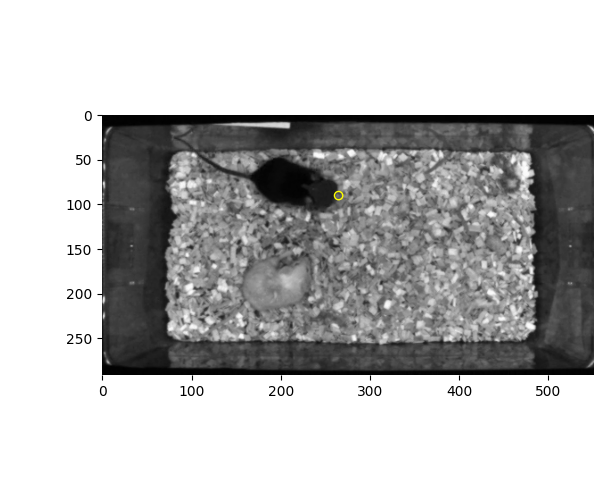

In [14]:
%matplotlib widget
kpms.noise_calibration(kpmoseq_dir, coordinates, confidences, **config())

>=90.0% of variance exlained by 6 components.


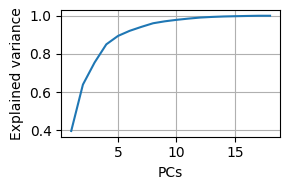

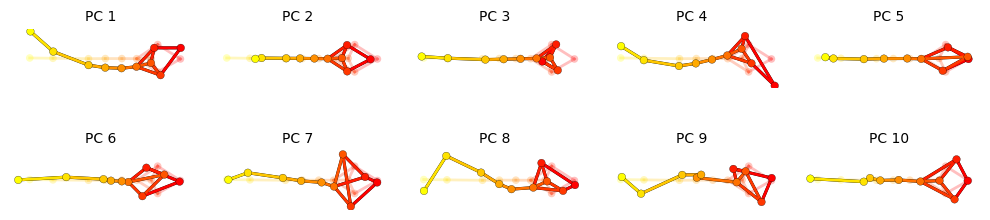

In [15]:
plt.close("all")
%matplotlib inline
pca = kpms.fit_pca(**data, **config())
kpms.save_pca(pca, kpmoseq_dir)

kpms.print_dims_to_explain_variance(pca, 0.9)
kpms.plot_scree(pca, project_dir=kpmoseq_dir)
kpms.plot_pcs(pca, project_dir=kpmoseq_dir, **config())

In [16]:
kpms.update_config(kpmoseq_dir, latent_dim=6) # >= 90.0% of the variance is explained by 6 components

In [17]:
kpms.update_config(
    kpmoseq_dir,
    sigmasq_loc=kpms.estimate_sigmasq_loc(data["Y"], data["mask"], filter_size=config()["fps"])
)

Fitting model with kappa=1000.0
Outputs will be saved to C:\Users\stagk\OneDrive\Desktop\trainingAggre
ssion_MR\trainingSessions\trainingSessions_topView_KPMS\my_kappa_scan-
1000.0


 49%|█████████████████▏                 | 25/51 [07:42<07:55, 18.30s/it]

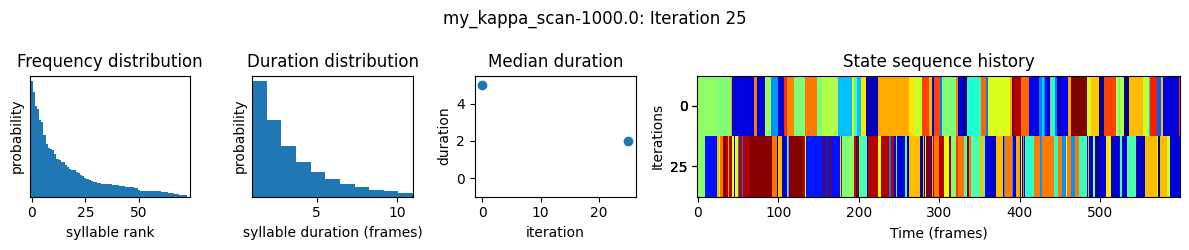

 98%|██████████████████████████████████▎| 50/51 [14:35<00:15, 15.44s/it]

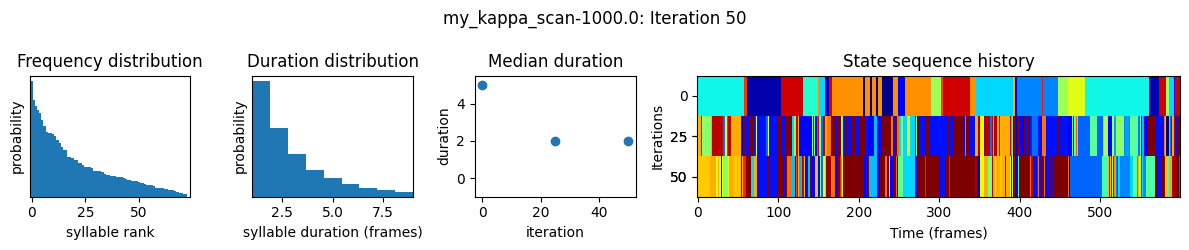

100%|███████████████████████████████████| 51/51 [14:52<00:00, 17.50s/it]


Outputs will be saved to C:\Users\stagk\OneDrive\Desktop\trainingAggre
ssion_MR\trainingSessions\trainingSessions_topView_KPMS\my_kappa_scan-
1000.0


 17%|████▊                        | 25/151 [1:17:30<6:56:31, 198.35s/it]

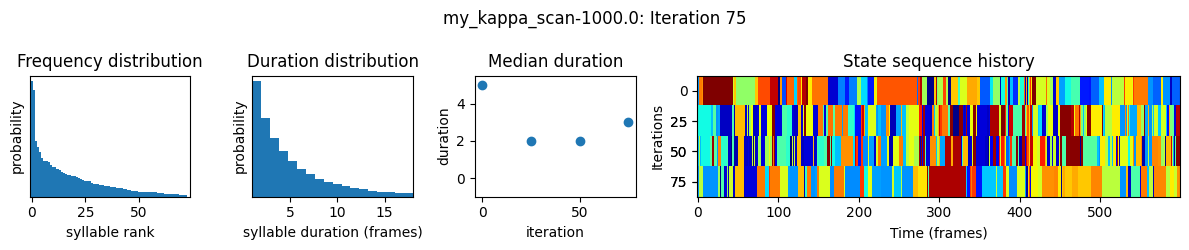

 33%|█████████▌                   | 50/151 [2:33:42<4:55:09, 175.34s/it]

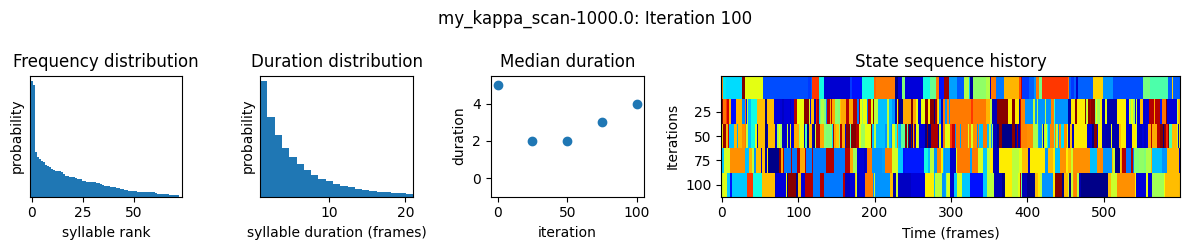

 50%|██████████████▍              | 75/151 [3:51:56<3:44:53, 177.55s/it]

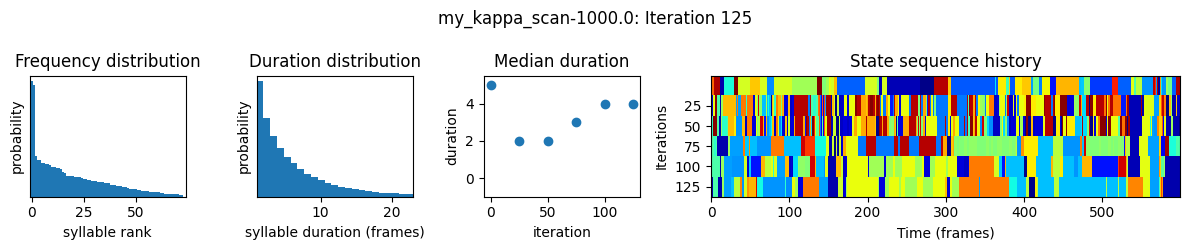

 66%|██████████████████▌         | 100/151 [5:10:28<2:33:52, 181.02s/it]

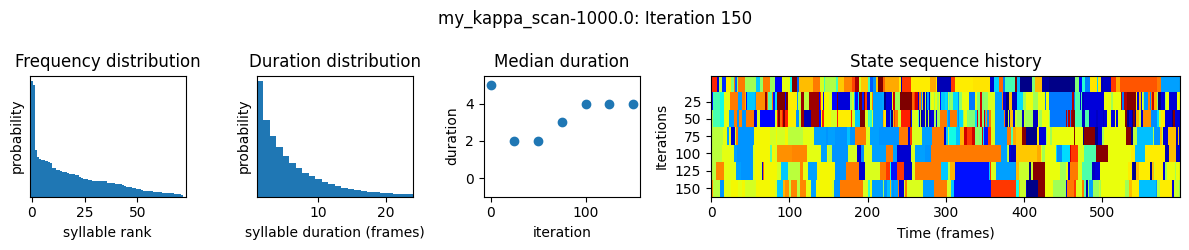

 83%|███████████████████████▏    | 125/151 [6:29:42<1:30:18, 208.39s/it]

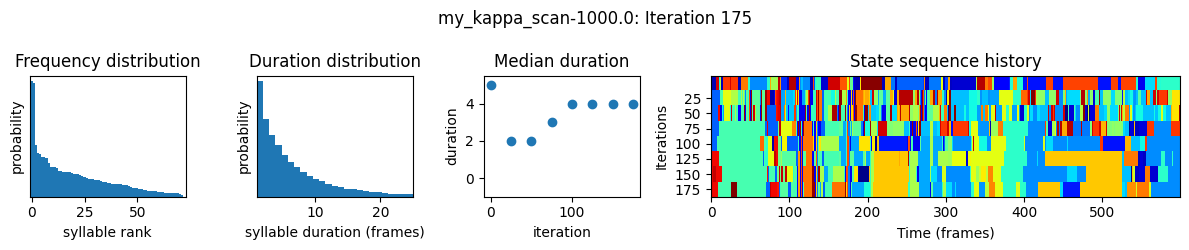

 99%|█████████████████████████████▊| 150/151 [7:46:17<02:56, 176.19s/it]

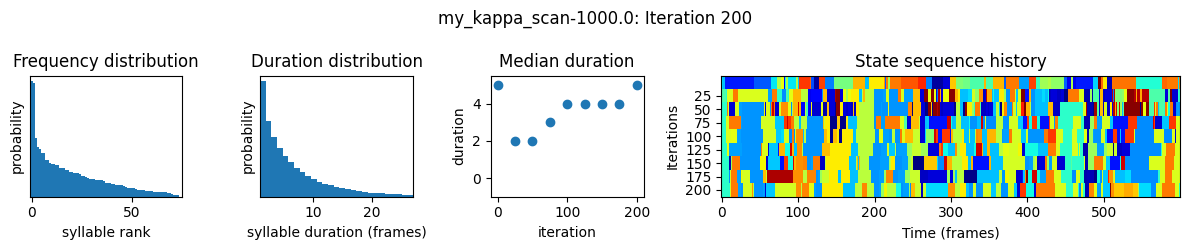

100%|██████████████████████████████| 151/151 [7:50:10<00:00, 186.82s/it]


Fitting model with kappa=10000.0
Outputs will be saved to C:\Users\stagk\OneDrive\Desktop\trainingAggre
ssion_MR\trainingSessions\trainingSessions_topView_KPMS\my_kappa_scan-
10000.0


 49%|█████████████████▏                 | 25/51 [07:17<07:06, 16.41s/it]

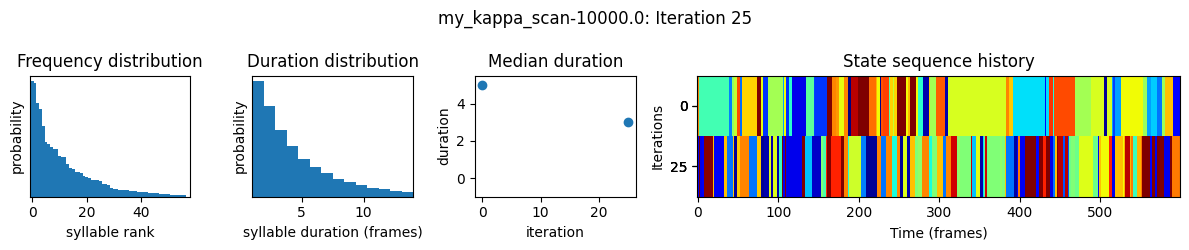

 98%|██████████████████████████████████▎| 50/51 [14:04<00:16, 16.05s/it]

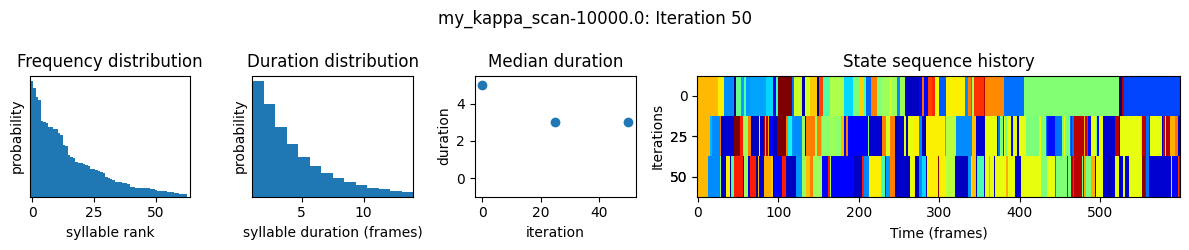

100%|███████████████████████████████████| 51/51 [14:22<00:00, 16.92s/it]


Outputs will be saved to C:\Users\stagk\OneDrive\Desktop\trainingAggre
ssion_MR\trainingSessions\trainingSessions_topView_KPMS\my_kappa_scan-
10000.0


 17%|████▊                        | 25/151 [1:19:12<7:02:01, 200.96s/it]

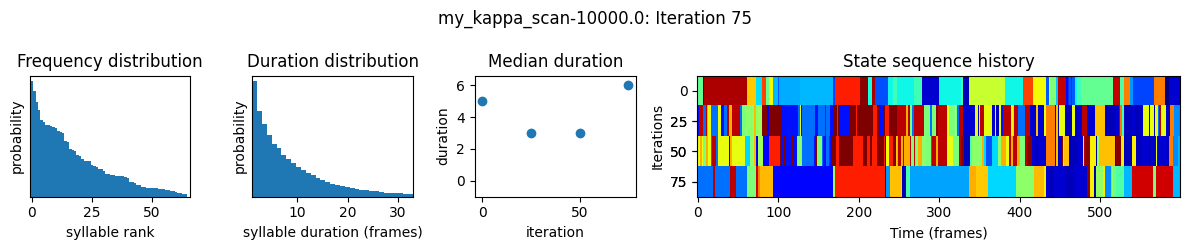

 33%|█████████▌                   | 50/151 [2:35:28<4:54:08, 174.74s/it]

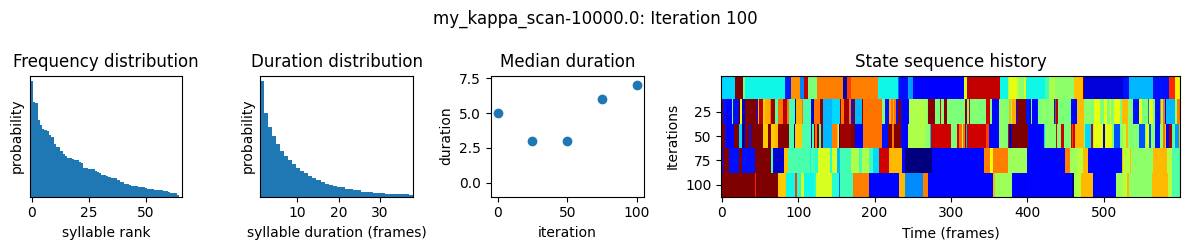

 50%|██████████████▍              | 75/151 [3:52:13<3:47:05, 179.28s/it]

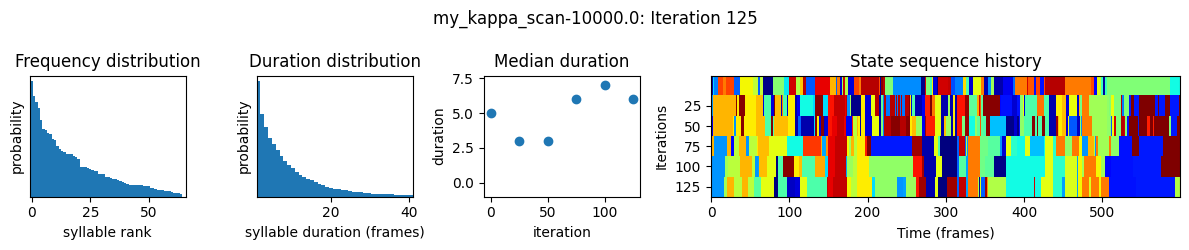

 66%|██████████████████▌         | 100/151 [5:06:44<2:23:40, 169.02s/it]

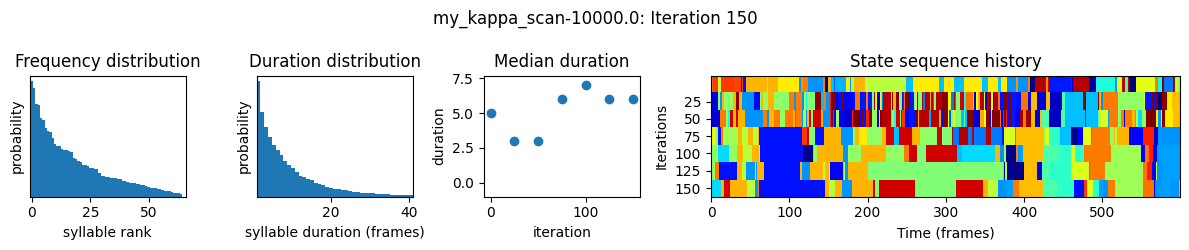

 83%|███████████████████████▏    | 125/151 [6:23:45<1:17:07, 177.97s/it]

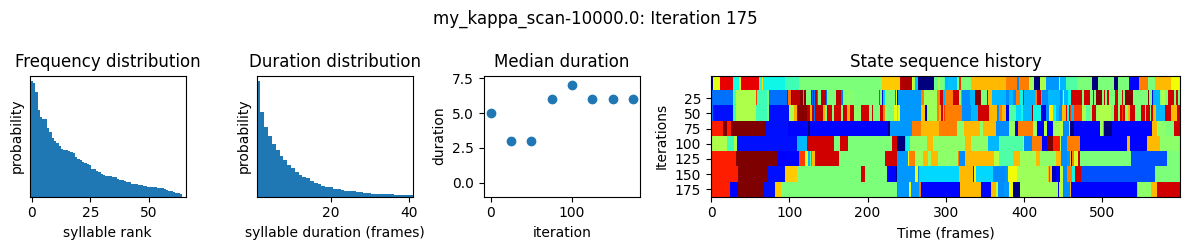

 99%|█████████████████████████████▊| 150/151 [7:39:48<03:09, 189.36s/it]

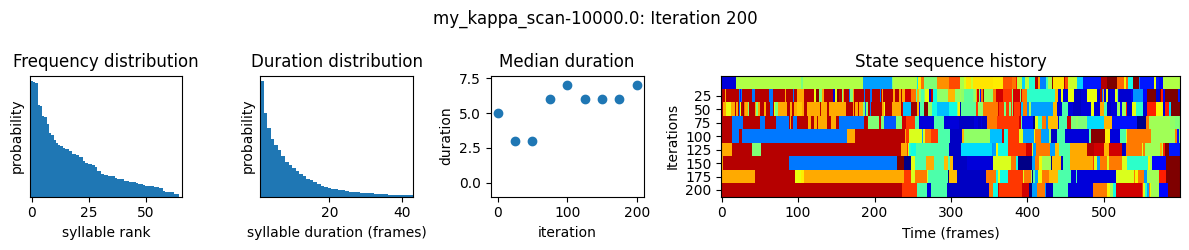

100%|██████████████████████████████| 151/151 [7:43:51<00:00, 184.31s/it]


Fitting model with kappa=100000.0
Outputs will be saved to C:\Users\stagk\OneDrive\Desktop\trainingAggre
ssion_MR\trainingSessions\trainingSessions_topView_KPMS\my_kappa_scan-
100000.0


 49%|█████████████████▏                 | 25/51 [06:45<06:55, 15.99s/it]

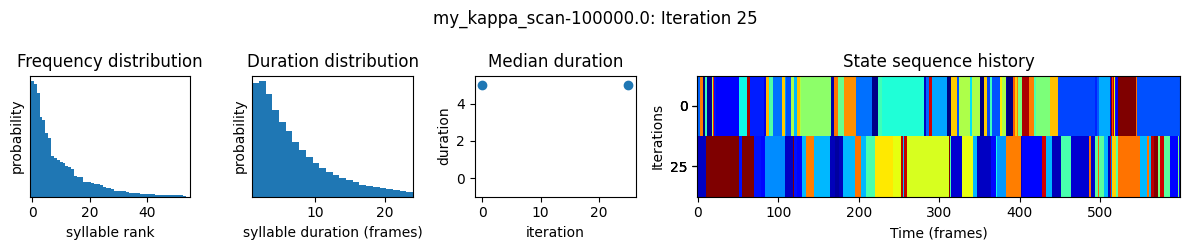

 98%|██████████████████████████████████▎| 50/51 [13:28<00:15, 15.97s/it]

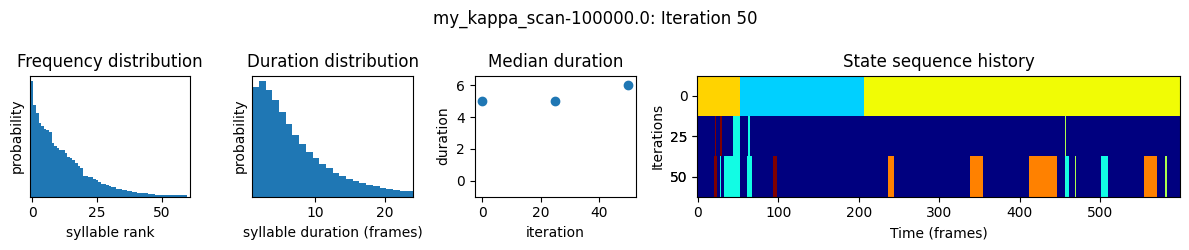

100%|███████████████████████████████████| 51/51 [13:45<00:00, 16.20s/it]


Outputs will be saved to C:\Users\stagk\OneDrive\Desktop\trainingAggre
ssion_MR\trainingSessions\trainingSessions_topView_KPMS\my_kappa_scan-
100000.0


 17%|████▊                        | 25/151 [1:16:06<6:31:17, 186.33s/it]

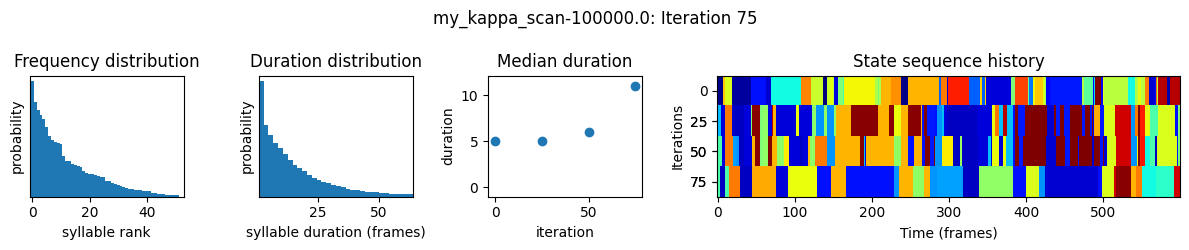

 33%|█████████▌                   | 50/151 [2:33:20<5:07:12, 182.50s/it]

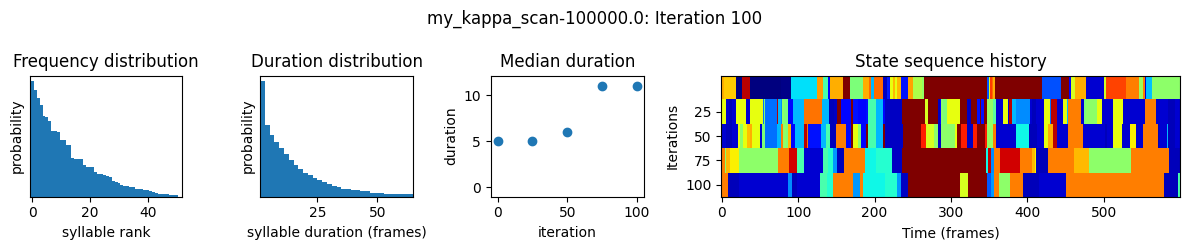

 50%|██████████████▍              | 75/151 [3:48:51<3:36:06, 170.61s/it]

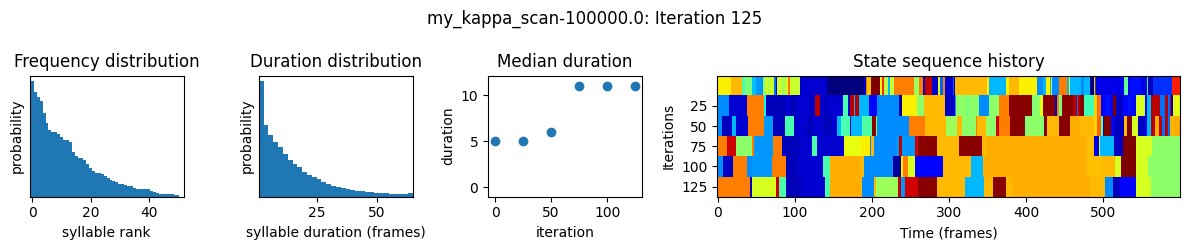

 66%|██████████████████▌         | 100/151 [5:07:12<2:46:46, 196.21s/it]

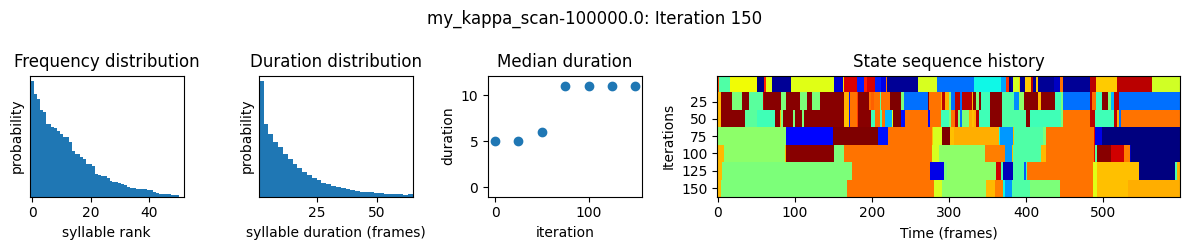

 83%|███████████████████████▏    | 125/151 [6:22:50<1:15:42, 174.69s/it]

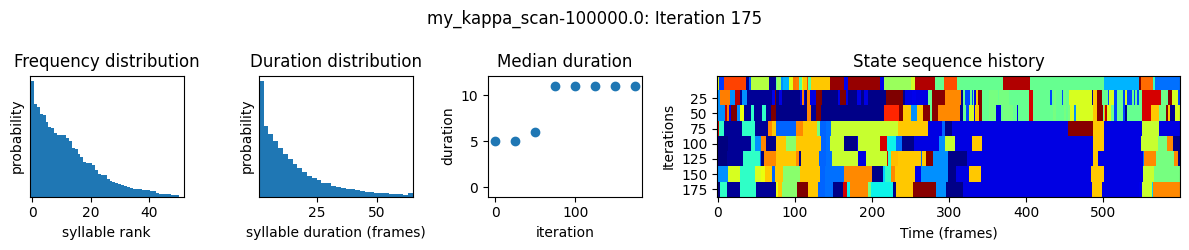

 99%|█████████████████████████████▊| 150/151 [7:40:52<03:27, 207.44s/it]

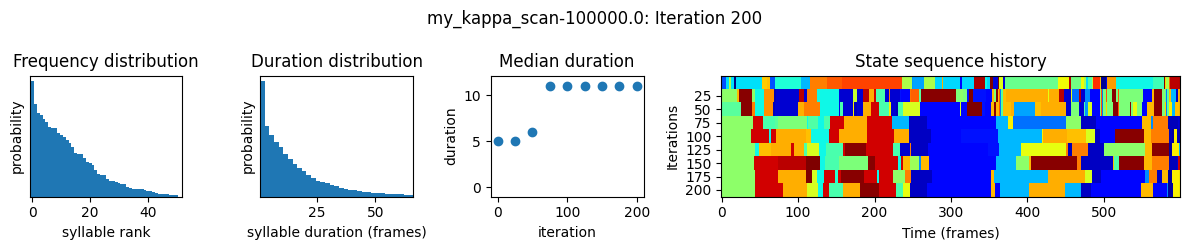

100%|██████████████████████████████| 151/151 [7:43:45<00:00, 184.27s/it]


Fitting model with kappa=1000000.0
Outputs will be saved to C:\Users\stagk\OneDrive\Desktop\trainingAggre
ssion_MR\trainingSessions\trainingSessions_topView_KPMS\my_kappa_scan-
1000000.0


 49%|█████████████████▏                 | 25/51 [06:43<06:59, 16.14s/it]

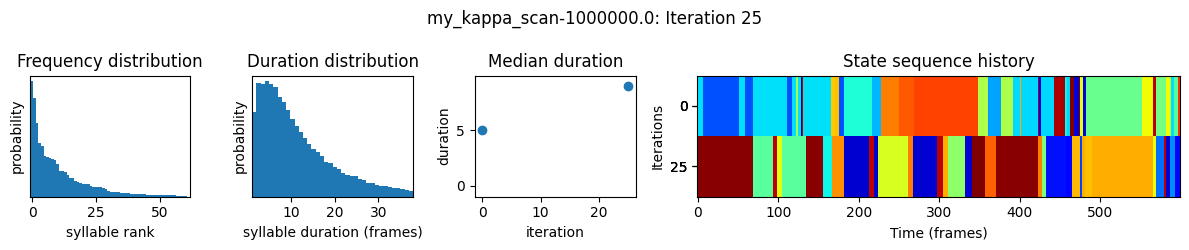

 98%|██████████████████████████████████▎| 50/51 [13:25<00:16, 16.12s/it]

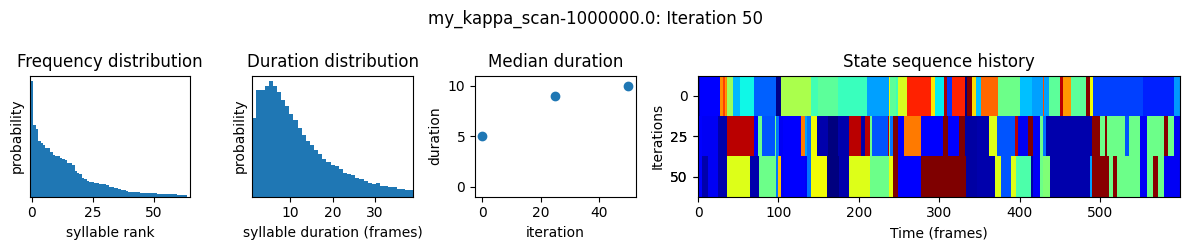

100%|███████████████████████████████████| 51/51 [13:42<00:00, 16.13s/it]


Outputs will be saved to C:\Users\stagk\OneDrive\Desktop\trainingAggre
ssion_MR\trainingSessions\trainingSessions_topView_KPMS\my_kappa_scan-
1000000.0


 17%|████▊                        | 25/151 [1:18:46<7:14:41, 207.00s/it]

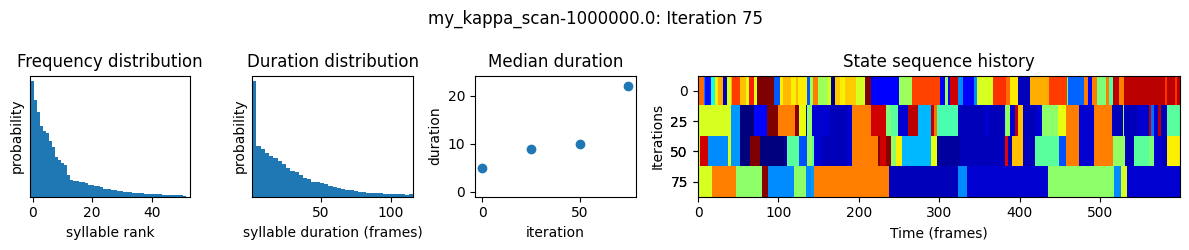

 33%|█████████▌                   | 50/151 [2:34:58<4:55:13, 175.38s/it]

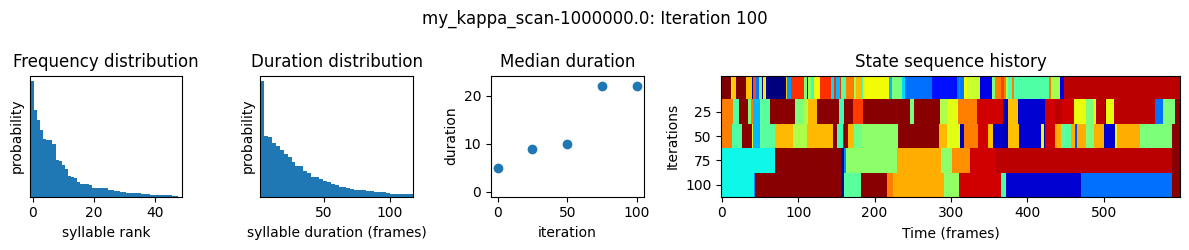

 50%|██████████████▍              | 75/151 [3:52:17<4:06:02, 194.24s/it]

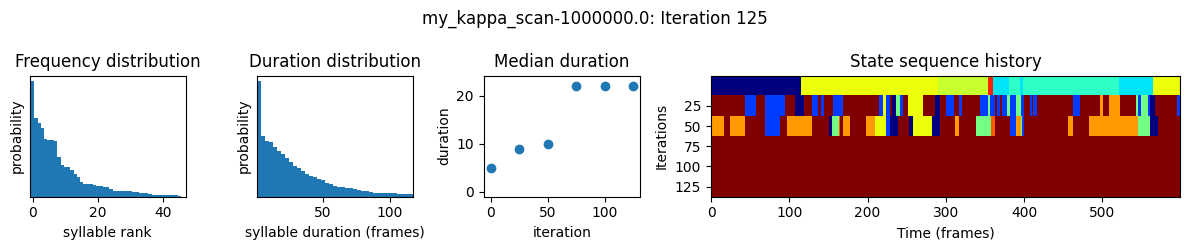

 66%|██████████████████▌         | 100/151 [5:09:35<2:42:08, 190.75s/it]

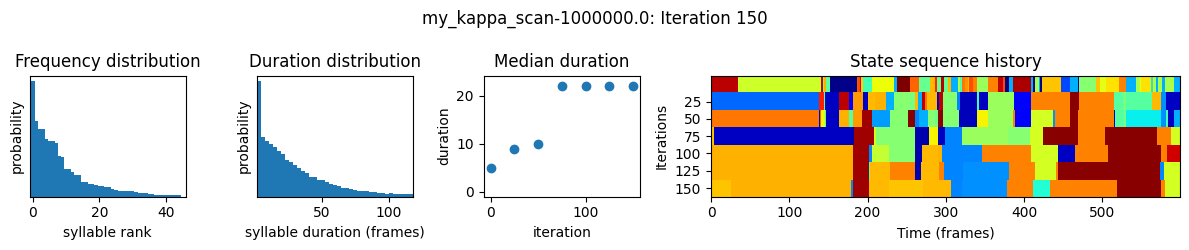

 83%|███████████████████████▏    | 125/151 [6:25:18<1:15:06, 173.32s/it]

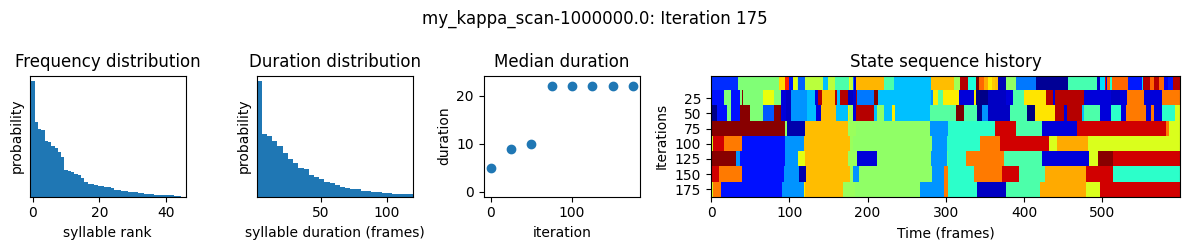

 99%|█████████████████████████████▊| 150/151 [7:42:14<02:58, 179.00s/it]

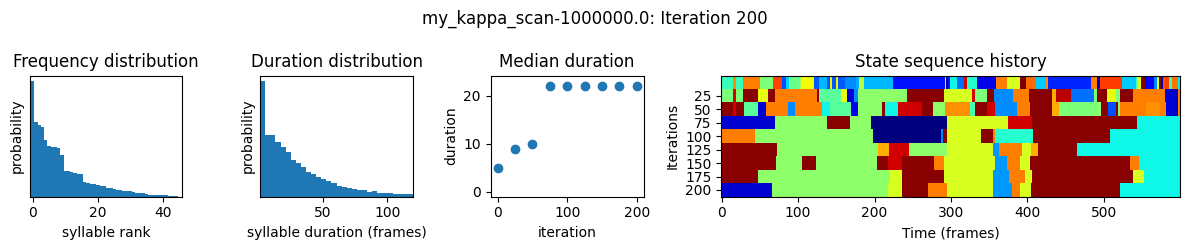

100%|██████████████████████████████| 151/151 [7:46:16<00:00, 185.27s/it]


Fitting model with kappa=10000000.0
Outputs will be saved to C:\Users\stagk\OneDrive\Desktop\trainingAggre
ssion_MR\trainingSessions\trainingSessions_topView_KPMS\my_kappa_scan-
10000000.0


 49%|█████████████████▏                 | 25/51 [07:02<06:41, 15.46s/it]

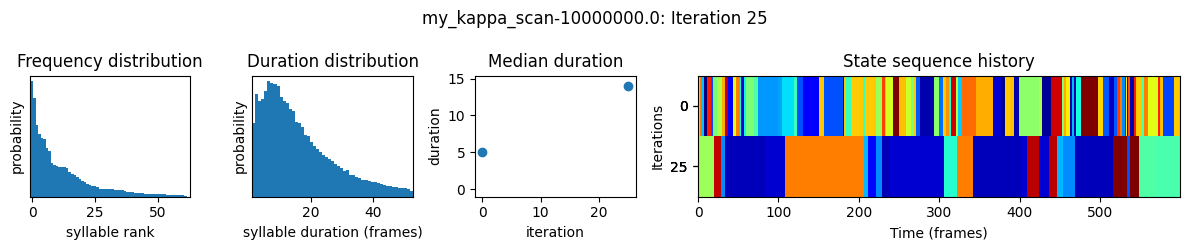

 98%|██████████████████████████████████▎| 50/51 [13:30<00:15, 15.43s/it]

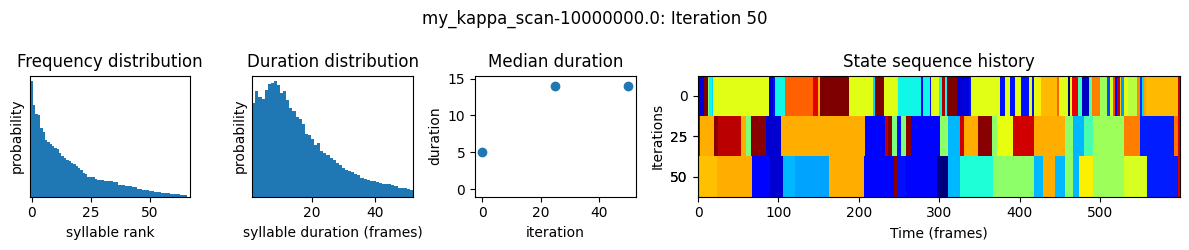

100%|███████████████████████████████████| 51/51 [13:46<00:00, 16.22s/it]


Outputs will be saved to C:\Users\stagk\OneDrive\Desktop\trainingAggre
ssion_MR\trainingSessions\trainingSessions_topView_KPMS\my_kappa_scan-
10000000.0


 17%|████▊                        | 25/151 [1:16:06<5:59:48, 171.34s/it]

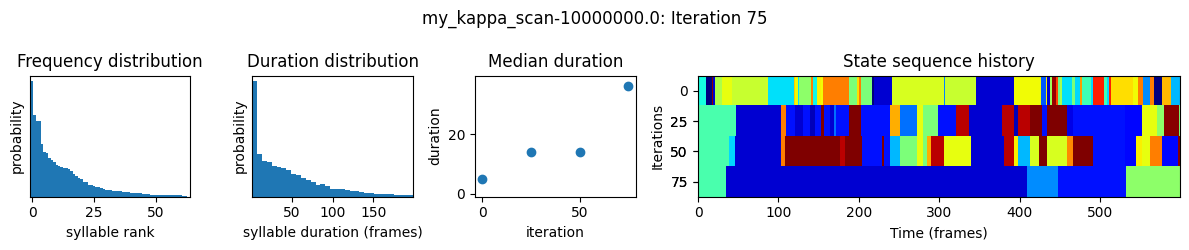

 33%|█████████▌                   | 50/151 [2:35:44<5:34:53, 198.94s/it]

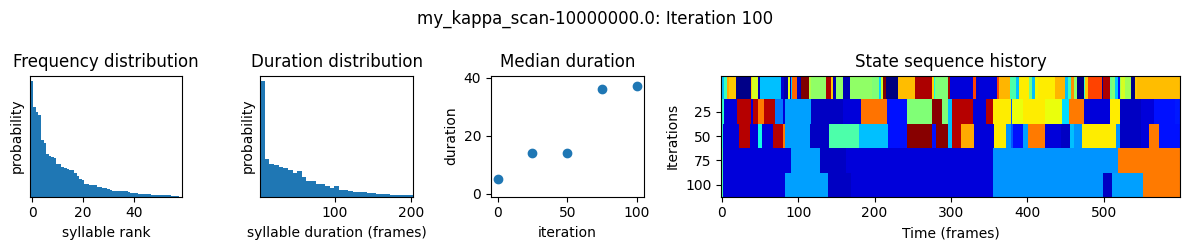

 50%|██████████████▍              | 75/151 [3:52:24<3:42:30, 175.66s/it]

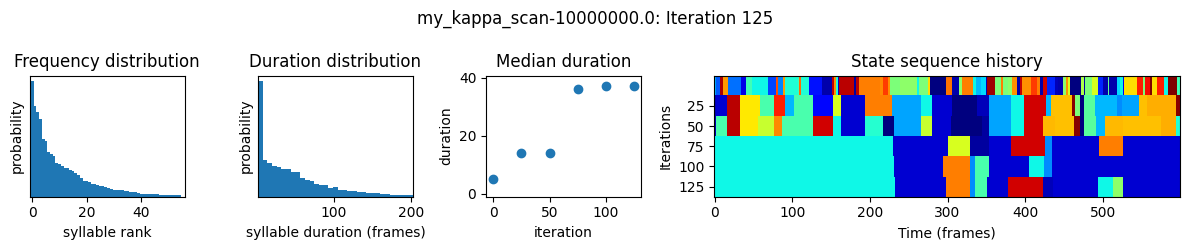

 66%|██████████████████▌         | 100/151 [5:09:18<2:25:09, 170.78s/it]

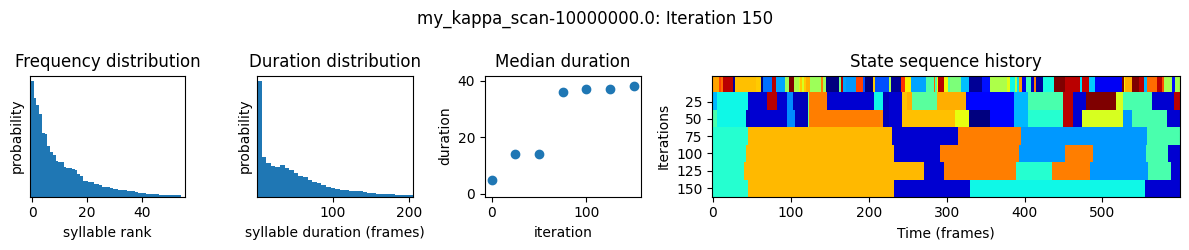

 83%|███████████████████████▏    | 125/151 [6:29:13<1:27:38, 202.26s/it]

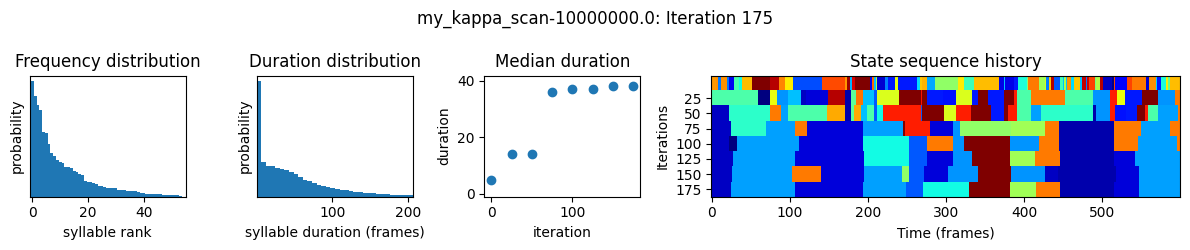

 99%|█████████████████████████████▊| 150/151 [7:47:36<03:14, 194.78s/it]

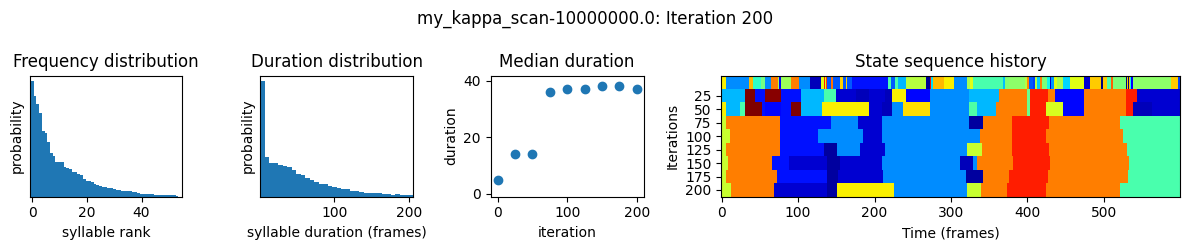

Loading checkpoints: 100%|██████████| 5/5 [00:01<00:00,  3.58it/s]


(<Figure size 800x250 with 2 Axes>, array([ 5.,  7., 11., 22., 37.]))

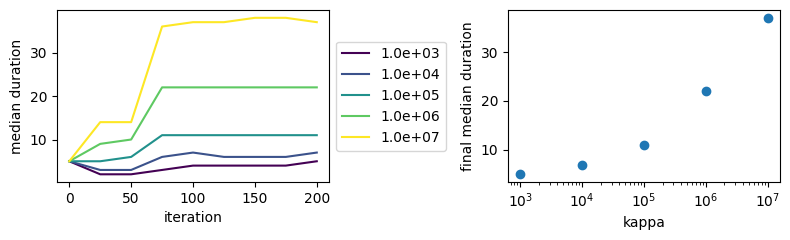

In [20]:
kappas = np.logspace(3,7,5)
decrease_kappa_factor = 10
num_ar_iters = 50
num_full_iters = 200

prefix = 'my_kappa_scan'

for kappa in kappas:
    print(f"Fitting model with kappa={kappa}")
    model_name = f'{prefix}-{kappa}'
    model = kpms.init_model(data, pca=pca, **config())

    # stage 1: fit the model with AR only
    model = kpms.update_hypparams(model, kappa=kappa)
    model = kpms.fit_model(
        model,
        data,
        metadata,
        kpmoseq_dir,
        model_name,
        ar_only=True,
        num_iters=num_ar_iters,
        save_every_n_iters=25
    )[0];

    # stage 2: fit the full model
    model = kpms.update_hypparams(model, kappa=kappa/decrease_kappa_factor)
    kpms.fit_model(
        model,
        data,
        metadata,
        kpmoseq_dir,
        model_name,
        ar_only=False,
        start_iter=num_ar_iters,
        num_iters=num_full_iters,
        save_every_n_iters=25
    );

kpms.plot_kappa_scan(kappas, kpmoseq_dir, prefix)

In [20]:
# load model checkpoint

num_ar_iters = 50
kappa = 1.0e5
model_name = "my_kappa_scan-100000.0"

model_to_fit, data, metadata, current_iter = kpms.load_checkpoint(
    kpmoseq_dir, model_name
)

# modify kappa to maintain the desired syllable time-scale
model_to_fit = kpms.update_hypparams(model_to_fit, kappa = kappa)

Outputs will be saved to C:\Users\stagk\OneDrive\Desktop\trainingAggre
ssion_MR\trainingSessions\trainingSessions_topView_KPMS\fullModel_1000
00.0


  8%|██▎                         | 25/301 [1:15:31<12:57:03, 168.92s/it]

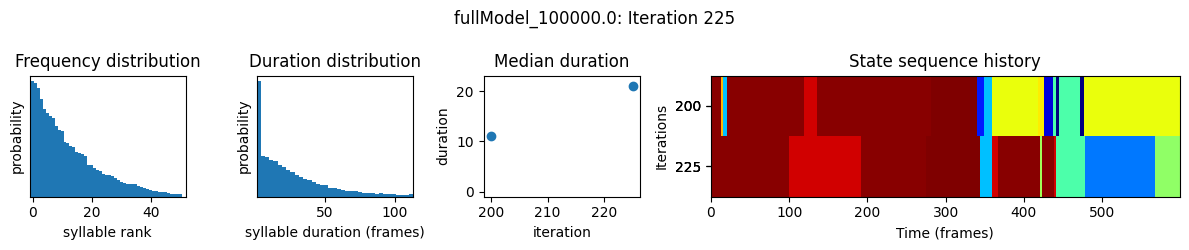

 17%|████▋                       | 50/301 [2:34:22<15:24:49, 221.07s/it]

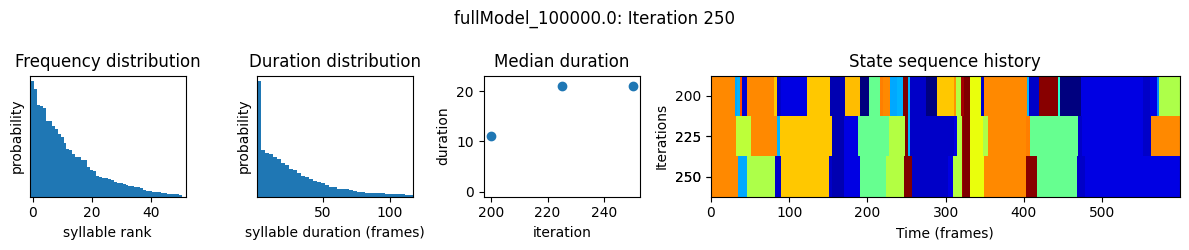

 25%|██████▉                     | 75/301 [3:48:34<10:26:41, 166.38s/it]

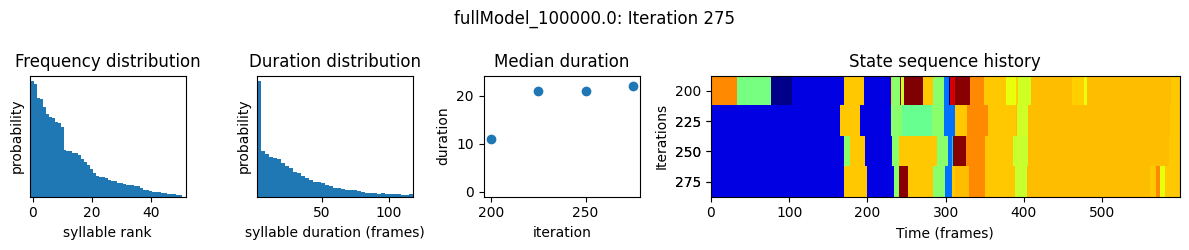

 33%|████████▉                  | 100/301 [5:06:52<10:29:07, 187.80s/it]

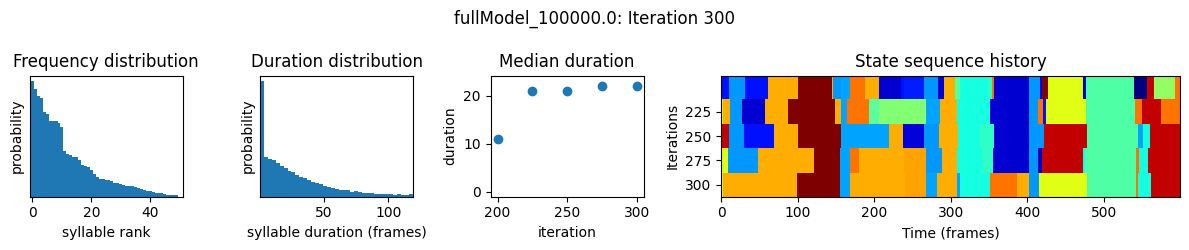

 42%|███████████▋                | 125/301 [6:21:54<9:25:59, 192.95s/it]

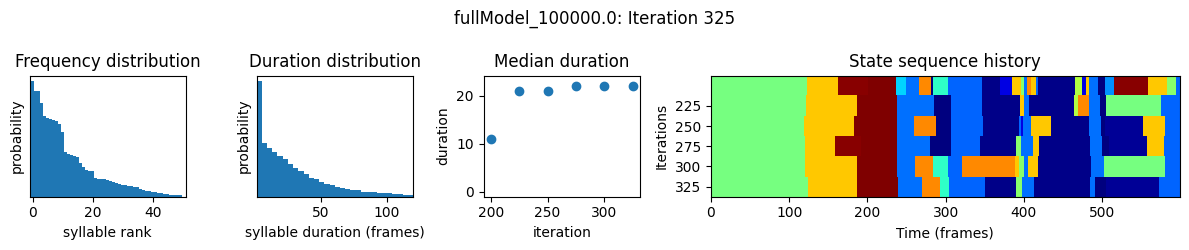

 50%|█████████████▉              | 150/301 [7:40:16<7:30:37, 179.06s/it]

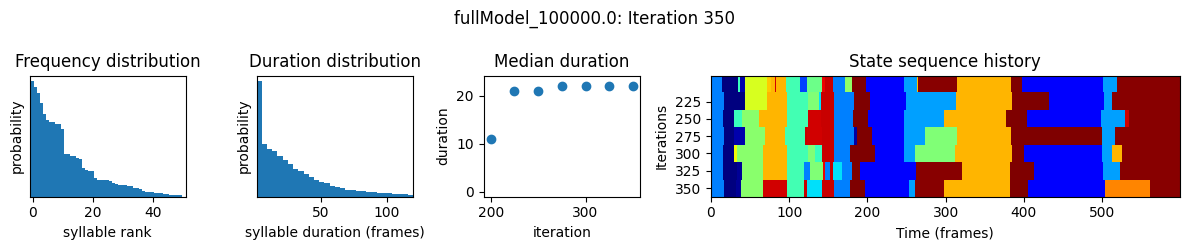

 58%|████████████████▎           | 175/301 [8:54:01<6:18:20, 180.16s/it]

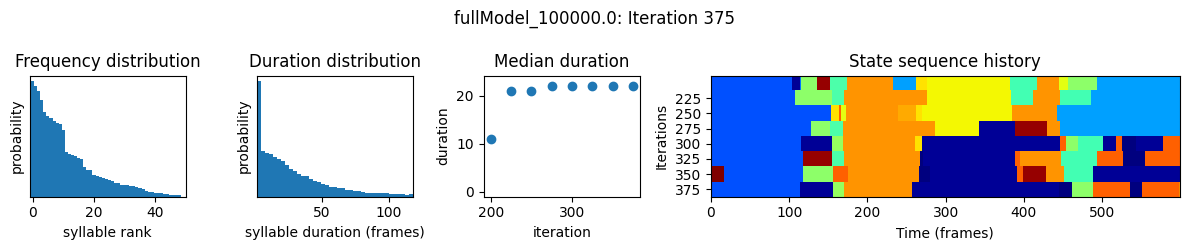

 66%|█████████████████▉         | 200/301 [10:13:29<4:56:37, 176.22s/it]

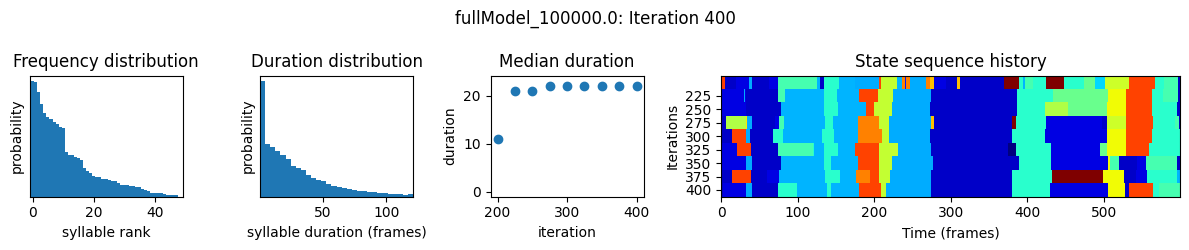

 75%|████████████████████▏      | 225/301 [11:29:09<3:31:49, 167.23s/it]

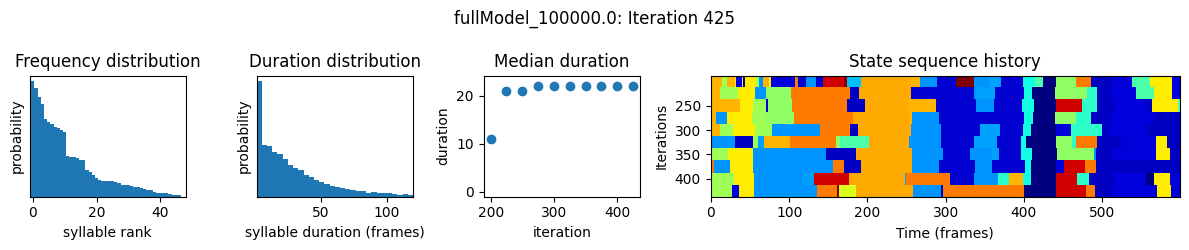

 83%|██████████████████████▍    | 250/301 [12:48:14<3:05:32, 218.29s/it]

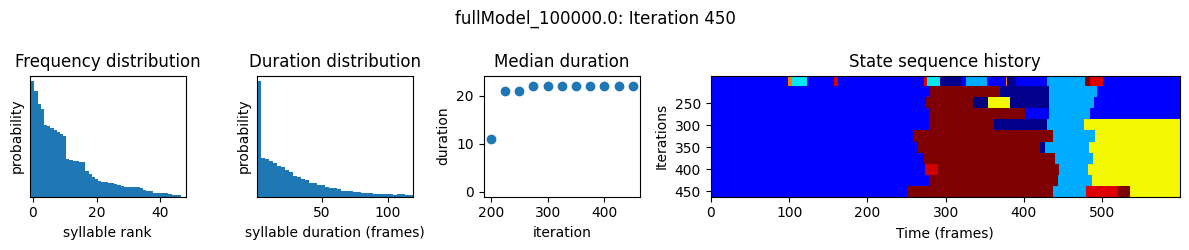

 91%|████████████████████████▋  | 275/301 [14:02:55<1:12:07, 166.46s/it]

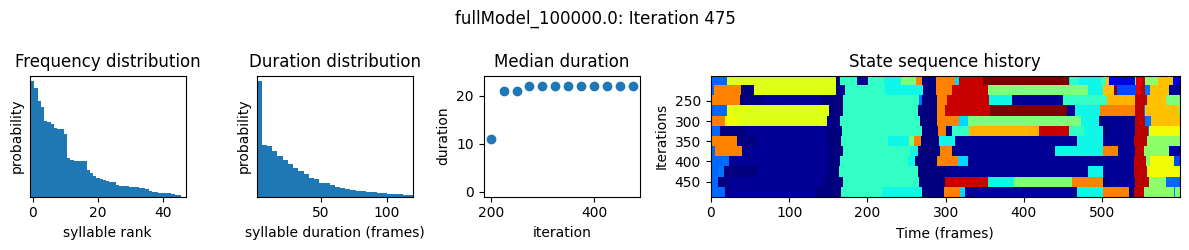

100%|████████████████████████████▉| 300/301 [15:22:32<03:01, 181.99s/it]

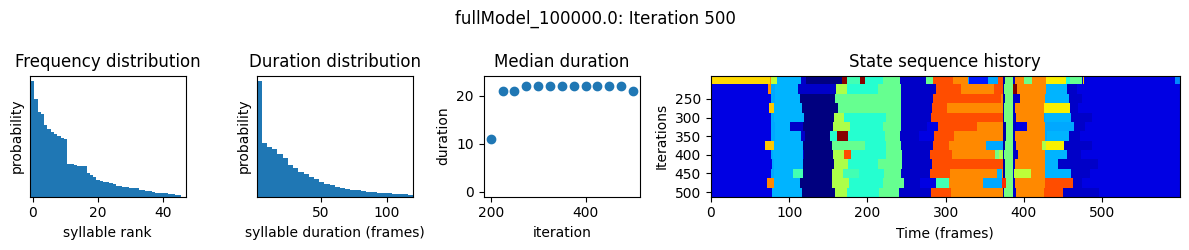

100%|█████████████████████████████| 301/301 [15:25:23<00:00, 184.46s/it]


In [22]:
# run fitting for an additional 300 iters
model = kpms.fit_model(
    model_to_fit,
    data,
    metadata,
    kpmoseq_dir,
    f"fullModel_{kappa}",
    ar_only=False,
    start_iter=current_iter,
    num_iters=current_iter + 300,
)[0]

In [10]:
model_name = "fullModel_100000.0"

# load the most recent model checkpoint
model, data, metadata, current_iter = kpms.load_checkpoint(kpmoseq_dir, model_name)

# extract results
results = kpms.extract_results(model, metadata, kpmoseq_dir, model_name)

Saved results to C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR
\trainingSessions\trainingSessions_topView_KPMS\fullModel_100000.0\res
ults.h5


Saving trajectory plots to C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\trainingSessions_topView_KPMS\fullModel_100000.0\trajectory_plots


Generating trajectory plots: 100%|██████| 34/34 [00:24<00:00,  1.38it/s]


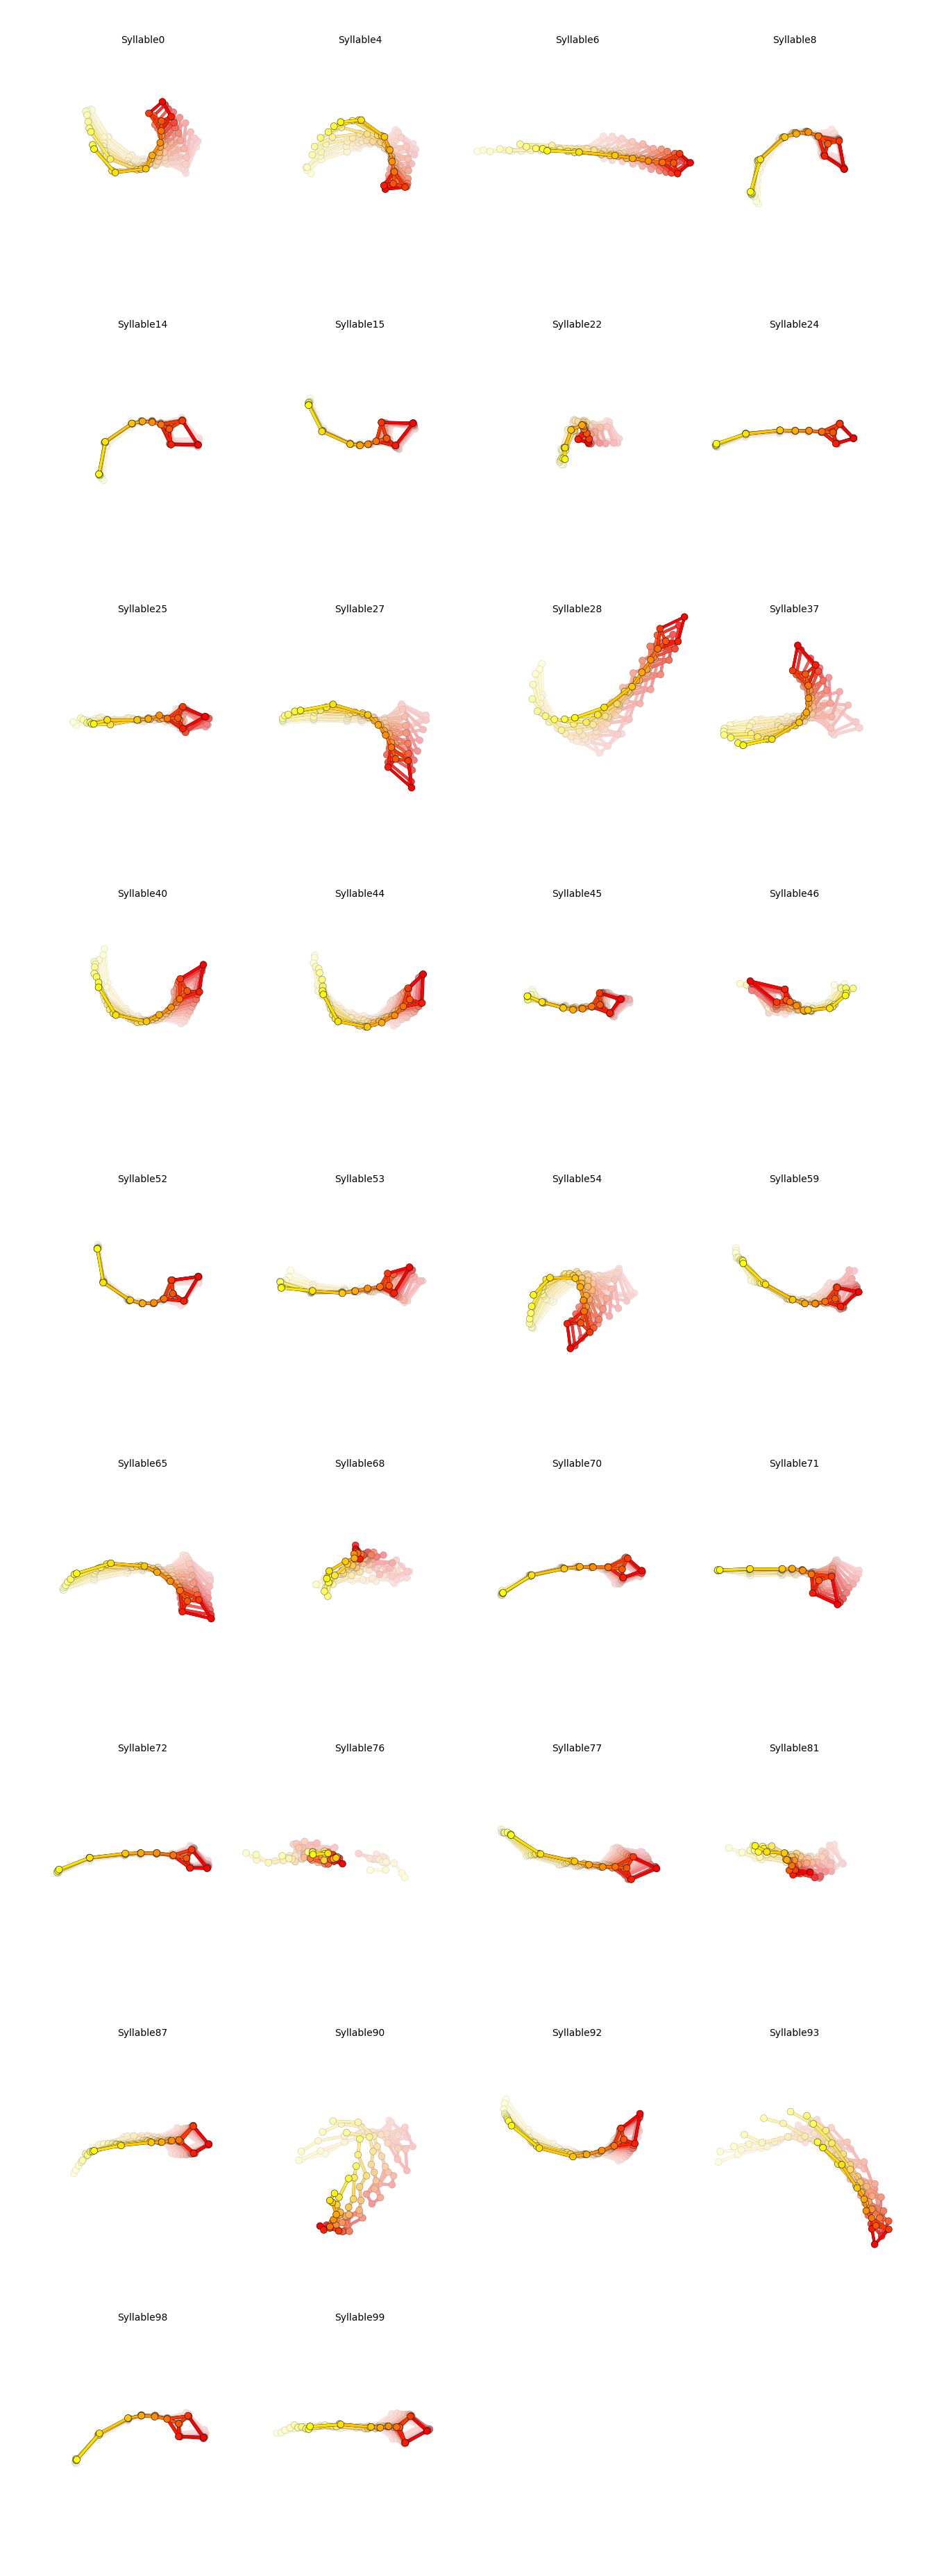

In [12]:
results = kpms.load_results(kpmoseq_dir, model_name)
kpms.generate_trajectory_plots(coordinates, results, kpmoseq_dir, model_name, **config())

In [13]:
kpms.generate_grid_movies(results, kpmoseq_dir, model_name, coordinates=coordinates, **config());


Writing grid movies to C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\trainingSessions_topView_KPMS\fullModel_100000.0\grid_movies
Using window size of 304 pixels


Generating grid movies: 100%|███████████| 34/34 [05:43<00:00, 10.11s/it]


Saving dendrogram plot to C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\trainingSessions_topView_KPMS\fullModel_100000.0\similarity_dendrogram


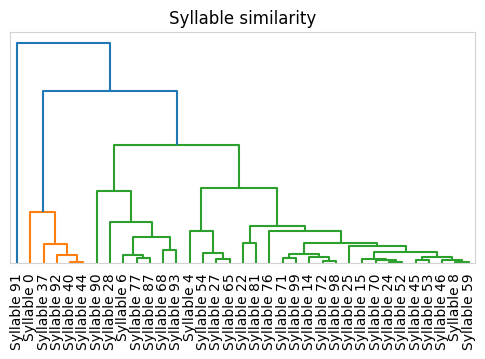

In [14]:
kpms.plot_similarity_dendrogram(coordinates, results, kpmoseq_dir, model_name, **config())